In [1]:
import sys
sys.path.append("../../src")

import os
import numpy as np
from numba import njit
from scipy.stats import ortho_group
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.PredictiveDecorrBSS_OlshaussenExp import PredictiveDecorrOlshaussen

In [2]:
import scipy.io

def get_olshausen_patches(IMAGES, n_patches=312500, patch_size=12):
    """
    Extracts random 12x12 patches from the Olshausen dataset.
    
    Args:
        IMAGES (ndarray): The [512, 512, 10] matrix from the .mat file.
        n_patches (int): Number of total patches to extract.
        patch_size (int): Width/Height of the square patches.
    """
    h, w, n_images = IMAGES.shape
    for ii in range(n_images):
        IMAGES[:, :, ii] /= IMAGES[:, :, ii].std()
    
    # Initialize the data matrix: (Pixels, Patches) -> (144, 100000)
    X = np.zeros((patch_size**2, n_patches))
    
    for i in range(n_patches):
        # 1. Select a random image
        img_idx = np.random.randint(n_images)
        # 2. Select a random top-left corner
        # We subtract patch_size to ensure we don't go out of bounds
        r = np.random.randint(0, h - patch_size)
        c = np.random.randint(0, w - patch_size)
        
        # 3. Extract and flatten the patch
        patch = IMAGES[r:r+patch_size, c:c+patch_size, img_idx].flatten()
        
        # --- EXTRA PREPROCESSING STEPS ---
        
        # A. Zero-Mean: Subtract the average brightness of this specific patch
        # This forces the network to learn the spatial contrast (edges)
        patch = patch #- np.mean(patch)
        
        # B. Normalization: Scale the patch to unit variance or a fixed range
        # This prevents 'blown out' patches from dominating the gradient
        # std = np.std(patch)
        # if std > 1e-6:
        #     patch = patch / std
            
        X[:, i] = patch
        
    return X

# Read Image Patches

In [3]:
image_paths = '../../data'
X = scipy.io.loadmat(os.path.join(image_paths,'imagepatcheselfwhitened.mat'))['IMAGES']

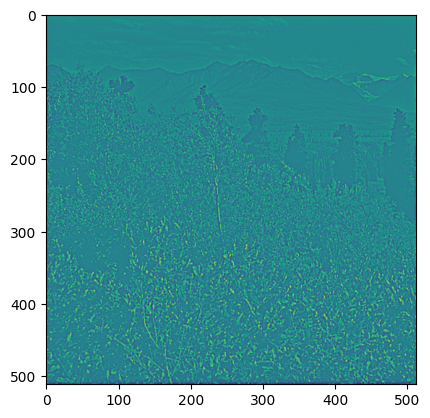

In [4]:
plt.imshow(X[:, :, 5])

In [5]:
seed = 0
np.random.seed(seed)
X_patches = get_olshausen_patches(X)
X_patches.shape

(144, 312500)

# Hyperparameters

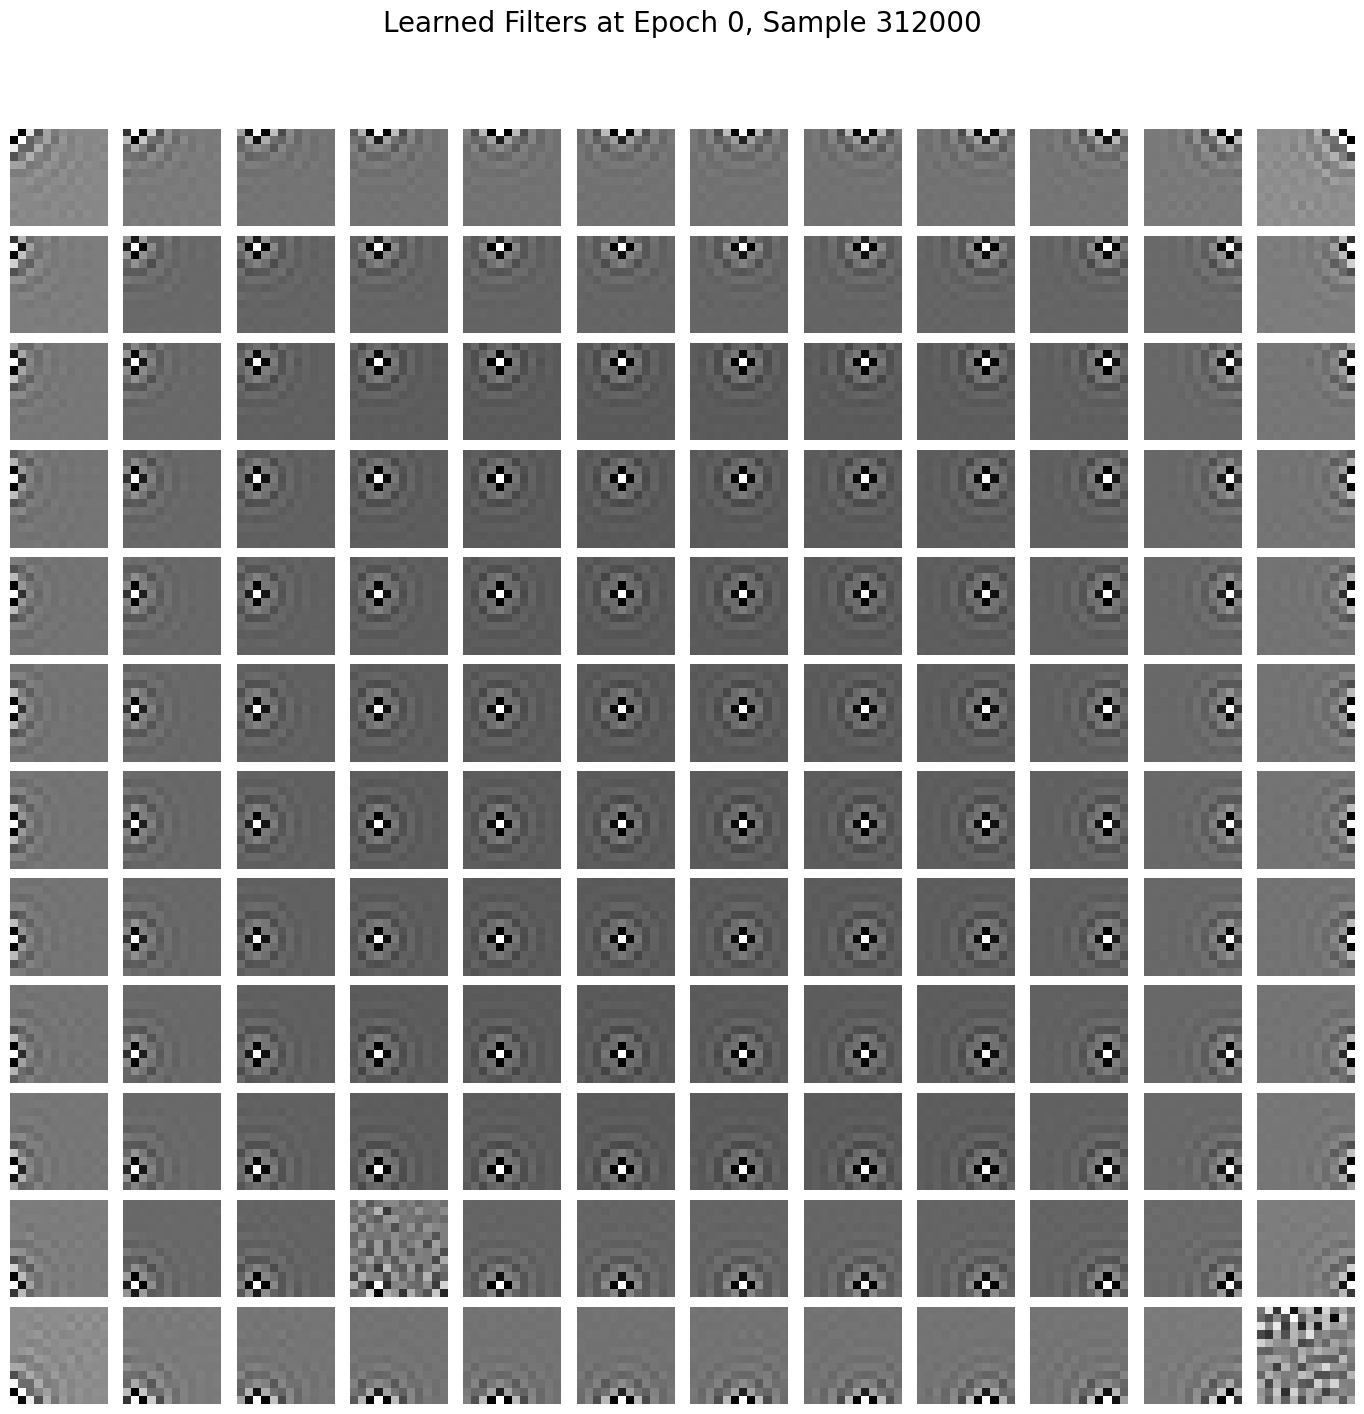

100%|███████████████████████████████████████████████████████████████████████████████████████████| 312500/312500 [16:28<00:00, 316.00it/s]


<Figure size 3600x2400 with 0 Axes>

In [6]:
np.random.seed(seed)
NumberofSources = 144
NumberofMixtures = 144
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 1 - 1e-3/7,
                "gamma_predictive" : 4,
                ### Learning rates 
                "lr_W" : 1e-3 / 4,
                "neural_lr_start" : 1.5,
                "neural_lr_stop" : 1e-8,
                "stlambda_lr" : 3e-2,
                "neural_dynamics_iterations" : 100,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "divide_by_log_index",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_slow_loop_index",
                "neural_lr_decay_divider" : 200,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : None,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrOlshaussen(**hyperparam_dict)
model.C_y = np.eye(NumberofSources) / 1. + np.random.randn(NumberofSources, NumberofSources) / 250
model.W = np.random.randn(NumberofSources, NumberofMixtures) / 250 + np.eye(NumberofSources, NumberofMixtures) * 1.0
model.fit(X_patches)

In [7]:
display_matrix(model.C_y[:5, :5])

<IPython.core.display.Math object>

In [8]:
display_matrix(model.mu_y.reshape(1, -1)[:, :5])

<IPython.core.display.Math object>

In [9]:
display_matrix(model.W[:5, :5])

<IPython.core.display.Math object>

In [10]:
lambdae = 1 - 1e-3 / 7
(1 - lambdae) / lambdae

0.000142877553936245

In [11]:
1.4e-4 * 20000

2.8